# BUS32120, Final
# Tuition Costs and Student Loan Debt

## API Data Set: Student Characteristics by University in the United States
Source: U.S. Department of Education, College Scorecard data
> Source website: __https://collegescorecard.ed.gov/data/api-documentation/__

## External Data Set: Borrowers with Student Loans in Delinquency

Source: Federal Reserve Bank of New York Center for Economic Data: "Student Loan Delinquencies, by State"
> Source Website: __https://www.newyorkfed.org/microeconomics/databank.html__

Dataframe: edu_frame

Date of analysis: February 5 - March 11, 2026

Analysts: 
-  Anna Brunner,
-  LeChae Mottley,
-  Thomas Reinhart

**Target audience:** The following analysis has been prepared for University Administrators (specifically 4-year, predominantly undergraduate institutions) to better understand the extent to which their institutions' undergraduate student loan borrowing aligns with median state salaries to determine the student loan debt burden for college graduates. 

**Purpose:** Many factors impact how much student loan debt a student takes on to go to college (e.g., cost of tuition, parent salaries, cost of living in the student's community, scholarships). As younger generations opt for alternatives to higher education due to the perceived lack of ROI, it is important to analyze the current financial landscape for college graduates. The following analysis allows University Administrators to understand the severity of the student loan debt challenge in the United States and determine the extent to which their students' loan debt burden may be more than their salaries can support.


# 1. Loading Packages and Fetching Data

<div class="alert alert-block alert-info">
<b>Note:</b> The College Scorecard API allows users to access 20 rows of data per page with the ability to increase the per page maximum to 100 rows. Users must conduct a loop to pull all rows of data, as completed below.
</div>

In [1]:
#importing data packages, setting API parameters
import requests
import json
from pprint import pprint
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np


api_url = "https://api.data.gov/ed/collegescorecard/v1/schools"
api_key = "E3bwidJHPskG7LJKOKCVdYe0Zt1I3a58MVRCZn1d"

In [2]:
params = {
    "api_key": api_key,
    "per_page": 100,
    "latest.school.degrees_awarded.predominant": 3,
    "fields": (
        "root.id," #identifier number
        "school.name," 
        "school.state,"
        "school.ownership," #private, public, propriety
        "school.religious_affiliation," #flag for schools with religious affiliation 
        "latest.student.enrollment.undergrad_12_month," #school enrollment counts over 12-month time period
        "latest.aid.federal_loan_rate," #rate of federal loans by school
        "latest.aid.median_debt.income.0_30000," #median amount of debt for students at graduation from household with income between 0-$30,000
        "latest.aid.median_debt.income.30001_75000," #" " $30,001-75,000
        "latest.aid.median_debt.income.greater_than_75000," #" " greater than $75,000
        "latest.aid.median_debt_suppressed.overall," #Median amount of debt at graduation for entire student population
        "latest.cost.tuition.in_state," #In-state tuition
        "latest.cost.tuition.out_of_state," #Out-of-state tuition
        "latest.school.degrees_awarded.predominant" #Reports if the school predominantly grants associates, bachelors, or graduate degrees
    )
}

In [3]:
response = requests.get(api_url, params=params)
print(response.status_code) #Checks for connection to the API

200


In [4]:
def fetch_edu(params, api_key, per_page=100):
        all_results = []
        page = 0
        
        while True:
            paged_params = params.copy() 
            paged_params.update({
                "api_key": api_key,
                "per_page": 100,
                "page": page
            })
            
            response = requests.get(api_url, params=paged_params)
            response.raise_for_status()
            data = response.json()
                
            results = data.get('results', [])
            all_results.extend(results)

            total = data["metadata"]["total"]
            print(f"Fetched {len(all_results)} records. Total records so far {len(all_results)}")

            if len(all_results) >= total or not results:
                break

            page += 1

        return pd.json_normalize(all_results)

In [5]:
#fetching API data using loop
edu_frame = fetch_edu(params,api_key)

Fetched 100 records. Total records so far 100
Fetched 200 records. Total records so far 200
Fetched 300 records. Total records so far 300
Fetched 400 records. Total records so far 400
Fetched 500 records. Total records so far 500
Fetched 600 records. Total records so far 600
Fetched 700 records. Total records so far 700
Fetched 800 records. Total records so far 800
Fetched 900 records. Total records so far 900
Fetched 1000 records. Total records so far 1000
Fetched 1100 records. Total records so far 1100
Fetched 1200 records. Total records so far 1200
Fetched 1300 records. Total records so far 1300
Fetched 1400 records. Total records so far 1400
Fetched 1500 records. Total records so far 1500
Fetched 1600 records. Total records so far 1600
Fetched 1700 records. Total records so far 1700
Fetched 1800 records. Total records so far 1800
Fetched 1900 records. Total records so far 1900
Fetched 1983 records. Total records so far 1983


# 2. Student Characteristics at the University Level

In [6]:
# reordering columns and simplifying column names
desired_order = ['school.name',
                'school.state',
                'school.ownership',
                'school.religious_affiliation',
                'latest.student.enrollment.undergrad_12_month',
                'latest.aid.federal_loan_rate',
                'latest.aid.median_debt.income.0_30000',
                'latest.aid.median_debt.income.30001_75000',
                'latest.aid.median_debt.income.greater_than_75000',
                'latest.aid.median_debt_suppressed.overall',
                'latest.cost.tuition.in_state',
                'latest.cost.tuition.out_of_state',
                'latest.school.degrees_awarded.predominant'
                ]

edu_frame = edu_frame[desired_order]

In [7]:
edu_frame.rename(columns={"school.name": "School",
                             "school.state": "State",
                             "school.ownership": "Ownership",
                             "school.religious_affiliation": "Religious Affiliation",
                             "latest.student.enrollment.undergrad_12_month": "Number of Undergrads Enrolled",
                             "latest.aid.federal_loan_rate": "Federal Loan Rate",
                             "latest.aid.median_debt.income.0_30000": "Median Debt, $0-$30,000 Income",
                             "latest.aid.median_debt.income.30001_75000": "Median Debt, $30,001-$75,000 Income",
                             "latest.aid.median_debt.income.greater_than_75000": "Median Debt, $75,000+ Income",
                             "latest.aid.median_debt_suppressed.overall": "Median Debt, All Income Brackets", 
                             "latest.cost.tuition.in_state": "In-State Tuition",
                             "latest.cost.tuition.out_of_state": "Out-of-State Tuition", 
                             "latest.school.degrees_awarded.predominant": "Predominantly Undergraduate Institution"}, inplace = True)

In [8]:
edu_frame = edu_frame.drop('Predominantly Undergraduate Institution', axis=1)

In [9]:
#summary statistics to identify null or suspect values
edu_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 1983 entries, 0 to 1982
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   School                               1983 non-null   str    
 1   State                                1983 non-null   str    
 2   Ownership                            1983 non-null   int64  
 3   Religious Affiliation                709 non-null    float64
 4   Number of Undergrads Enrolled        1979 non-null   float64
 5   Federal Loan Rate                    1969 non-null   float64
 6   Median Debt, $0-$30,000 Income       1769 non-null   float64
 7   Median Debt, $30,001-$75,000 Income  1724 non-null   float64
 8   Median Debt, $75,000+ Income         1721 non-null   float64
 9   Median Debt, All Income Brackets     1811 non-null   float64
 10  In-State Tuition                     1887 non-null   float64
 11  Out-of-State Tuition                 1887

In [10]:
#checking for anomalies and data validity
edu_frame.describe()

,Ownership,Religious Affiliation,Number of Undergrads Enrolled,Federal Loan Rate,"Median Debt, $0-$30,000 Income","Median Debt, $30,001-$75,000 Income","Median Debt, $75,000+ Income","Median Debt, All Income Brackets",In-State Tuition,Out-of-State Tuition
count,1983.000000,709.000000,1979.000000,1969.000000,1769.000000,1724.000000,1721.000000,1811.000000,1887.000000,1887.000000
mean,1.776097,55.520451,5471.681152,0.446410,15720.847937,16386.739559,16296.884370,15969.274986,25280.521993,28886.171701
std,0.575565,21.983717,11099.329197,0.221806,4738.880209,4373.233002,4124.561127,4412.342958,17200.367209,15506.437172
min,1.000000,22.000000,5.000000,0.000000,3500.000000,2750.000000,2750.000000,3500.000000,945.000000,945.000000
25%,1.000000,30.000000,770.000000,0.300000,12500.000000,13122.000000,13280.000000,12868.500000,10484.000000,16775.000000
50%,2.000000,54.000000,1914.000000,0.459600,15423.000000,16000.000000,15828.000000,15750.000000,19290.000000,26110.000000
75%,2.000000,71.000000,5307.000000,0.612800,18987.000000,19500.000000,19500.000000,19283.000000,37325.000000,38819.000000
max,3.000000,110.000000,215698.000000,1.000000,39742.000000,34096.000000,27166.000000,33443.000000,69330.000000,69330.000000


In [11]:
# check maximum number of undergrads enrolled due to it being significantly higher than expected
edu_frame_sorted = edu_frame.sort_values(by='Number of Undergrads Enrolled', ascending=False)
edu_frame_sorted.head(10)

,School,State,Ownership,Religious Affiliation,Number of Undergrads Enrolled,Federal Loan Rate,"Median Debt, $0-$30,000 Income","Median Debt, $30,001-$75,000 Income","Median Debt, $75,000+ Income","Median Debt, All Income Brackets",In-State Tuition,Out-of-State Tuition
837,Southern New Hampshire University,NH,2,NaN,215698.0,0.5907,7836.0,9999.0,11083.0,9169.0,16450.0,16450.0
1720,Western Governors University,UT,2,NaN,167263.0,0.4261,7219.0,8540.0,9602.0,8318.0,8300.0,8300.0
1886,University of Phoenix-Arizona,AZ,3,NaN,112151.0,0.6037,15000.0,19953.0,18466.0,16690.0,9552.0,9552.0
38,Grand Canyon University,AZ,3,NaN,102837.0,0.5350,10764.0,13842.0,15000.0,12500.0,17450.0,17450.0
1775,American Public University System,WV,3,NaN,78136.0,0.1329,9500.0,10484.0,13280.0,10282.0,8400.0,8400.0
571,University of Maryland Global Campus,MD,1,NaN,76378.0,0.1757,9500.0,11698.0,12000.0,10500.0,7992.0,12336.0
1530,Liberty University,VA,2,102.0,70898.0,0.4902,13935.0,16666.0,16892.0,15943.0,21222.0,21222.0
35,Arizona State University Campus Immersion,AZ,1,NaN,70646.0,0.2840,13750.0,13750.0,13245.0,13610.0,12051.0,32193.0
227,University of Central Florida,FL,1,NaN,68470.0,0.2421,15000.0,14201.0,15745.0,15000.0,6368.0,22467.0
1882,Arizona State University Digital Immersion,AZ,1,NaN,68215.0,0.3715,13750.0,13750.0,13245.0,13610.0,NaN,NaN


Due to the maximum number of undergraduate enrollments being significantly higher than expected, we manually searched and reviewed the enrollments of the top ten universities with the highest number of undergraduate students. Internet searches found that these universities are predominantly online institutions. Because these universities still have student characteristic data, student loan information, and other variables, we determined that we would not remove them from our dataframe.

In [12]:
# check minimum number of undergrads enrolled due to the minimum value being significantly lower than expected
edu_frame_sorted = edu_frame.sort_values(by='Number of Undergrads Enrolled', ascending=True)
edu_frame_sorted.head(20)

,School,State,Ownership,Religious Affiliation,Number of Undergrads Enrolled,Federal Loan Rate,"Median Debt, $0-$30,000 Income","Median Debt, $30,001-$75,000 Income","Median Debt, $75,000+ Income","Median Debt, All Income Brackets",In-State Tuition,Out-of-State Tuition
1891,University of West Los Angeles,CA,3,NaN,5.0,0.1429,NaN,NaN,NaN,NaN,NaN,NaN
1935,The Chicago School at San Diego,CA,2,NaN,7.0,0.5000,9500.0,10500.0,11250.0,10250.0,20844.0,20844.0
127,Notre Dame de Namur University,CA,2,30.0,9.0,NaN,18750.0,17500.0,12000.0,16500.0,NaN,NaN
1824,Fairfax University of America,VA,2,NaN,12.0,0.0000,NaN,NaN,NaN,NaN,10128.0,10128.0
324,American Islamic College,IL,2,NaN,13.0,0.0000,NaN,NaN,NaN,NaN,7650.0,7650.0
1008,Talmudical Institute of Upstate New York,NY,2,NaN,14.0,0.0000,NaN,NaN,NaN,NaN,6150.0,6150.0
94,Sofia University,CA,3,NaN,14.0,0.6000,NaN,NaN,NaN,NaN,NaN,NaN
1931,Yeshiva Bais Aharon,NJ,2,NaN,16.0,0.0000,NaN,NaN,NaN,NaN,10350.0,10350.0
1872,DeVry University-Nevada,NV,3,NaN,17.0,0.3000,11756.0,14317.0,14750.0,12805.0,17488.0,17488.0
1963,NewU University,DC,2,NaN,18.0,0.0000,NaN,NaN,NaN,NaN,16500.0,16500.0


In [13]:
#change null values to zeroes to include them in the religious affiliation dictionary map
edu_frame.fillna({"Religious Affiliation":0}, inplace=True)

,School,State,Ownership,Religious Affiliation,Number of Undergrads Enrolled,Federal Loan Rate,"Median Debt, $0-$30,000 Income","Median Debt, $30,001-$75,000 Income","Median Debt, $75,000+ Income","Median Debt, All Income Brackets",In-State Tuition,Out-of-State Tuition
0,Alabama A & M University,AL,1,0.0,5664.0,0.5859,17500.0,16000.0,15000.0,16600.0,10024.0,18634.0
1,University of Alabama at Birmingham,AL,1,0.0,14713.0,0.4097,16666.0,15985.0,15000.0,15832.0,8832.0,21864.0
2,Amridge University,AL,2,74.0,329.0,0.7237,12875.0,18803.0,19917.0,13385.0,NaN,NaN
3,University of Alabama in Huntsville,AL,1,0.0,8021.0,0.3391,14502.0,13075.0,13954.0,13905.0,11770.0,24662.0
4,Alabama State University,AL,1,0.0,3641.0,0.7776,17750.0,17000.0,18500.0,17500.0,11248.0,19576.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1978,Arizona College of Nursing-Sarasota,FL,3,0.0,76.0,0.8000,9500.0,9500.0,10250.0,9500.0,23093.0,23093.0
1979,Arizona College of Nursing-Aurora,CO,3,0.0,145.0,NaN,9500.0,9500.0,10250.0,9500.0,23760.0,23760.0
1980,Arizona College of Nursing-Cincinnati,OH,3,0.0,38.0,NaN,9500.0,9500.0,10250.0,9500.0,23760.0,23760.0
1981,Arizona College of Nursing-Cleveland,OH,3,0.0,52.0,NaN,9500.0,9500.0,10250.0,9500.0,23760.0,23760.0


In [14]:
edu_frame['Religious Affiliation'] = edu_frame['Religious Affiliation'].astype('int64')

In [15]:
#used the data dictionary of the data source to map the values to the name of the religious affiliation
rel_aff_map = {

-1:'Not Reported',
-2: 'Not Applicable',
22:'American Evangelical Lutheran Church',
24:'African Methodist Episcopal Zion Church',
27:'Assemblies of God Church',
28:'Brethren Church',
30:'Roman Catholic',
33:'Wisconsin Evangelical Lutheran Synod',
34:'Christ and Missionary Alliance Church',
35:'Christian Reformed Church',
36:'Evangelical Congregational Church',
37:'Evangelical Covenant Church of America',
38:'Evangelical Free Church of America',
39:'Evangelical Lutheran Church',
40:'International United Pentecostal Church',
41:'Free Will Baptist Church',
42:'Interdenominational',
43:'Mennonite Brethren Church',
44:'Moravian Church',
45:'North American Baptist',
47:'Pentecostal Holiness Church',
48:'Christian Churches and Churches of Christ',
49:'Reformed Church in America',
50:'Episcopal Church, Reformed',
51:'African Methodist Episcopal',
52:'American Baptist',
53:'American Lutheran',
54:'Baptist',
55:'Christian Methodist Episcopal',
57:'Church of God',
58:'Church of Brethren',
59:'Church of the Nazarene',
60:'Cumberland Presbyterian',
61:'Christian Church (Disciples of Christ)',
64:'Free Methodist',
65:'Friends',
66:'Presbyterian Church (USA)',
67:'Lutheran Church in America',
68:'Lutheran Church - Missouri Synod',
69:'Mennonite Church',
71:'United Methodist',
73:'Protestant Episcopal',
74:'Churches of Christ',
75:'Southern Baptist',
76:'United Church of Christ',
77:'Protestant, not specified',
78:'Multiple Protestant Denomination',
79:'Other Protestant',
80:'Jewish',
81:'Reformed Presbyterian Church',
84:'United Brethren Church',
87:'Missionary Church Inc',
88:'Undenominational',
89:'Wesleyan',
91:'Greek Orthodox',
92:'Russian Orthodox',
93:'Unitarian Universalist',
94:'Latter Day Saints (Mormon Church)',
95:'Seventh Day Adventists',
97:'The Presbyterian Church in America',
99:'Other (none of the above)',
100:'Original Free Will Baptist',
101:'Ecumenical Christian',
102:'Evangelical Christian',
103:'Presbyterian',
105:'General Baptist',
106:'Muslim',
107:'Plymouth Brethren',
108:'Non-Denominational',
110:'Orthodox Christian',
0:'Not Religiously Affiliated'

}

In [16]:
#apply the mapping to the religious affiliation column
edu_frame['Religious Affiliation'] = edu_frame['Religious Affiliation'].map(rel_aff_map)

In [17]:
#analyzed the extent of differences in median in-state tuition grouped by religious affiliation
edu_frame.groupby('Religious Affiliation', observed=True).agg({
    'Number of Undergrads Enrolled': 'sum',
    'In-State Tuition': 'median'
}).sort_values(by='In-State Tuition', ascending=False).reset_index()

,Religious Affiliation,Number of Undergrads Enrolled,In-State Tuition
0,Moravian Church,2109.0,52000.0
1,Lutheran Church in America,4267.0,49294.0
2,Evangelical Lutheran Church,44222.0,42865.0
3,The Presbyterian Church in America,894.0,40464.0
4,Roman Catholic,529167.0,38043.0
5,Mennonite Church,2412.0,37760.0
6,Christian Reformed Church,4962.0,37315.0
7,Church of Brethren,3258.0,37090.0
8,Presbyterian Church (USA),59281.0,36680.0
9,Lutheran Church - Missouri Synod,16445.0,36258.0


In [18]:
#analyzed the extent of differences in median debt grouped by religious affiliation
edu_frame.groupby('Religious Affiliation')[('Median Debt, All Income Brackets')].median().sort_values(ascending=False).reset_index()

,Religious Affiliation,"Median Debt, All Income Brackets"
0,Moravian Church,22000.0
1,Lutheran Church in America,21566.5
2,Original Free Will Baptist,20811.0
3,Evangelical Lutheran Church,20197.5
4,Evangelical Covenant Church of America,19875.0
5,"Episcopal Church, Reformed",19500.0
6,Church of God,19500.0
7,Evangelical Free Church of America,19500.0
8,Friends,19500.0
9,Roman Catholic,19392.5


Religious affiliation can have a significant effect on a student's cost of tuition, whereas, non-religiously affiliated universities have an average in-state tuition near the bottom of the distribution. In contrast, students in non-religiously affiliated universities are not as equally likely to be at the bottom of the distribution for student loan debt. This tells us that these religiously affiliated universities may have significant funding for scholarships or parents that have more resources. Because these "outliers" are accurately inputted and are simply a subset of the larger data, we chose not to drop these values as the only way to do so would be arbitrary.

In [19]:
#average filling nulls and dropping rows with nulls
low_avg = edu_frame['Median Debt, $0-$30,000 Income'].mean()
edu_frame['Median Debt, $0-$30,000 Income'] = edu_frame['Median Debt, $0-$30,000 Income'].fillna(low_avg)
medium_avg = edu_frame['Median Debt, $30,001-$75,000 Income'].mean()
edu_frame['Median Debt, $30,001-$75,000 Income'] = edu_frame['Median Debt, $30,001-$75,000 Income'].fillna(medium_avg)
high_avg = edu_frame['Median Debt, $75,000+ Income'].mean()
edu_frame['Median Debt, $75,000+ Income'] = edu_frame['Median Debt, $75,000+ Income'].fillna(high_avg)
all_avg = edu_frame['Median Debt, All Income Brackets'].mean()
edu_frame['Median Debt, All Income Brackets'] = edu_frame['Median Debt, All Income Brackets'].fillna(all_avg)

In [20]:
edu_frame = edu_frame.dropna(subset=['Number of Undergrads Enrolled'])
edu_frame = edu_frame.dropna(subset=['Federal Loan Rate'])
edu_frame = edu_frame.dropna(subset=['In-State Tuition'])
edu_frame = edu_frame.dropna(subset=['Out-of-State Tuition'])

Because each of the median debt series in our analysis include students with highly correlated financial features, as well as because there are only about 12 percent of null values, we determined that an average column fill for our null debt values would be appropriate.

In contrast, due to the large variance in the in-state and out-of-state tuition series, as well as the minimal number of schools with null tuition, undergraduate enrollment, and percent with federal loan results, we determined that dropping these rows would be appropriate.

In [21]:
edu_frame['In-State Tuition'] = pd.to_numeric(
    edu_frame['In-State Tuition'].replace(r'[\$,]', '', regex=True), 
    errors='coerce'
)

In [22]:
#feature engineering a column that establishes size subset for the number of undergrads enrolled
undergrads_enrolled = edu_frame['Number of Undergrads Enrolled']
def get_school_size(undergrads_enrolled):
    if undergrads_enrolled > 100000:
        return 'Extra Large'
    elif undergrads_enrolled > 30000:
        return 'Large'
    elif undergrads_enrolled > 5000:
        return 'Medium'
    elif undergrads_enrolled > 500:
        return 'Small'
    else:
        return 'Extra Small'

In [23]:
#check for completed feature
get_school_size(240000)

'Extra Large'

In [24]:
edu_frame['School Size'] = edu_frame['Number of Undergrads Enrolled'].apply(get_school_size)

In [25]:
#review of the median debt grouped by school size
edu_frame.groupby('School Size')[('Median Debt, All Income Brackets')].median().sort_values(ascending=False)

School Size
Small          16753.000000
Extra Small    15969.274986
Medium         15000.000000
Large          14038.000000
Extra Large    10834.500000
Name: Median Debt, All Income Brackets, dtype: float64

In [26]:
#review of the in-state tuition grouped by school size
edu_frame.groupby('School Size')[('In-State Tuition')].median().sort_values(ascending=False)

School Size
Small          31725.0
Extra Small    14345.0
Extra Large    13001.0
Large          11790.0
Medium         11188.0
Name: In-State Tuition, dtype: float64

On the whole, we find that students that attend smaller schools are more likely to have higher debt and higher in-state tuition. The most significant difference in these groupings show that students in small schools experience a more than twice as high in-state tuition bill than their extra small school and extra large school counterparts.

In [27]:
#create a linear regression to see the relationship between median debt, in-state tuition, and number of undergrads
X = edu_frame.drop(columns=["School", "State", "Ownership", "Religious Affiliation", "Median Debt, $0-$30,000 Income", 
                            "Median Debt, $30,001-$75,000 Income", "Median Debt, $75,000+ Income", 
                            "School Size", "Median Debt, All Income Brackets"]).astype(float)
y = edu_frame.loc[:,["Median Debt, All Income Brackets"]].astype(float)

In [28]:
edu_model = LinearRegression()
edu_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
edu_model.coef_

array([[-2.64661725e-02,  4.57584879e+03,  1.40492186e-02,
         9.32757480e-02]])

In [30]:
edu_model.intercept_

array([11057.54119762])

In [31]:
X['intercept']= 1 

In [32]:
edu_linreg = sm.OLS(y, X)

results = edu_linreg.fit()

#### Model #1: Linear Regression

In [33]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     Median Debt, All Income Brackets   R-squared:                       0.261
Model:                                          OLS   Adj. R-squared:                  0.260
Method:                               Least Squares   F-statistic:                     165.9
Date:                              Wed, 11 Mar 2026   Prob (F-statistic):          1.01e-121
Time:                                      14:09:14   Log-Likelihood:                -18089.
No. Observations:                              1881   AIC:                         3.619e+04
Df Residuals:                                  1876   BIC:                         3.622e+04
Df Model:                                         4                                         
Covariance Type:                          nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Number of Undergrads Enrolled    -0.0265      0.008     -3.159      0.002      -0.043      -0.010
Federal Loan Rate              4575.8488    391.828     11.678      0.000    3807.384    5344.314
In-State Tuition                  0.0140      0.014      1.007      0.314      -0.013       0.041
Out-of-State Tuition              0.0933      0.015      6.174      0.000       0.064       0.123
intercept                      1.106e+04    243.822     45.351      0.000    1.06e+04    1.15e+04
==============================================================================
Omnibus:                       19.317   Durbin-Watson:                   1.725
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.944
Skew:                          -0.054   Prob(JB):                     3.15e-07
Kurtosis:                       3.609   Cond. No.                     2.29e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.29e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Our linear regression found minimal relationship between our variables at only a 0.26 adjusted R-squared. This finding means that there are likely other factors that contribute to the amount of median debt that students carry. Factors can include their parent's income, scholarship funding, and other variables.

In [34]:
#rounds the values to the nearest integer and converts to an integer
edu_frame['Number of Undergrads Enrolled'] = edu_frame['Number of Undergrads Enrolled'].round().astype('int64')
edu_frame['Median Debt, All Income Brackets'] = edu_frame['Median Debt, All Income Brackets'].round().astype('int64')

In [35]:
#calculating amount of student loan debt each school's students carry
edu_frame["University Debt Load"] = edu_frame["Number of Undergrads Enrolled"] * \
    edu_frame["Median Debt, All Income Brackets"] * \
    edu_frame["Federal Loan Rate"]

In [36]:
edu_frame["University Debt Load"] = edu_frame["University Debt Load"] / 1000000

In [37]:
#Renames the column to make the title reflect the data stored in it
edu_frame.rename(columns={"University Debt Load": "University Debt Load (millions)"}, inplace = True)

In [38]:
#Creates a new column and converts to percentage string rather than decimal and leaves missing values unchanged
edu_frame["Percent with Federal Loans"] = edu_frame["Federal Loan Rate"].apply(lambda x: f"{x * 100:.2f}%" if x is not None and pd.notnull(x) else x)

In [39]:
#reports median in-state tuition by each state
edu_frame.groupby('State')[('In-State Tuition')].median().sort_values(ascending=False)

State
VT    45550.0
MA    45170.0
RI    42666.0
IA    35534.0
PA    33120.0
WI    32318.0
KS    32073.0
CT    31080.0
OH    30962.0
IL    30910.0
IN    30240.0
OR    30002.0
MN    25000.0
MI    24842.0
KY    24575.0
CA    23460.0
DC    22246.0
ME    22194.0
NH    21356.0
VA    20585.0
TN    20573.0
WA    19920.0
MO    19686.0
NC    19593.0
NE    19121.5
NY    17711.0
SC    17523.0
AZ    17488.0
FL    17119.0
NJ    15978.0
GA    14258.0
MD    14160.0
DE    13440.0
NV    13315.0
TX    13099.0
AR    13014.0
AL    12426.0
CO    12385.0
HI    12186.0
ND    10857.0
MS    10606.5
LA    10271.5
ID    10028.0
AK     9785.0
WV     9674.0
SD     9633.0
OK     9595.0
UT     9315.0
MT     8083.0
NM     7991.5
WY     6938.0
GU     6656.5
PR     5966.0
VI     5612.0
Name: In-State Tuition, dtype: float64

In [40]:
#reports median debt for $0-$30k households grouped by state
edu_frame.groupby('State')[('Median Debt, $0-$30,000 Income')].median().sort_values(ascending=False)

State
PA    19000.000000
MA    18575.500000
MI    17724.000000
RI    17250.000000
IL    16600.000000
VT    16596.000000
MS    16583.000000
OR    16512.000000
AL    16375.000000
CT    16000.000000
NH    15990.423968
SC    15875.000000
MD    15735.423968
VA    15735.423968
ID    15720.847937
DC    15720.847937
OH    15720.847937
NY    15720.847937
NC    15720.847937
WA    15720.847937
SD    15720.847937
CA    15720.847937
NJ    15720.847937
IA    15473.000000
NE    15077.500000
WI    15059.000000
GA    15000.000000
TN    14875.000000
FL    14875.000000
DE    14860.000000
LA    14854.500000
ME    14750.000000
MO    14518.000000
TX    14500.000000
KY    14287.500000
KS    14226.000000
IN    14010.000000
HI    14000.000000
WV    14000.000000
MN    14000.000000
NM    13986.500000
CO    13554.500000
GU    13110.423968
AR    12981.000000
OK    12750.000000
NV    12750.000000
WY    12500.000000
AZ    12500.000000
MT    12407.000000
AK    12318.000000
ND    12031.000000
UT    10255.000000
VI    

#### Figure 1: Histogram of In-State Tuition Frequencies

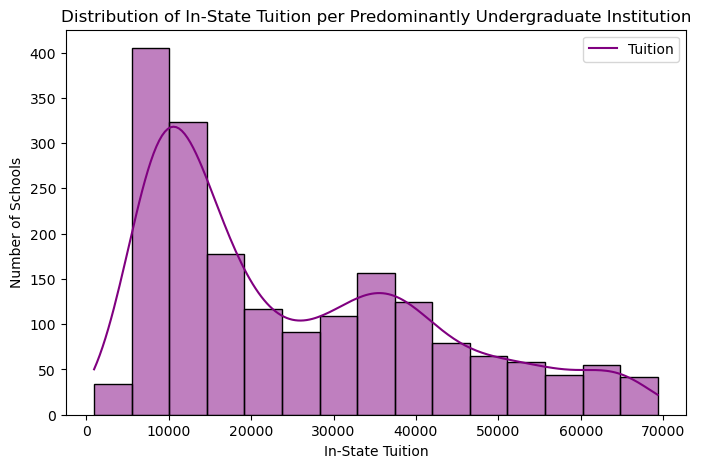

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    edu_frame["In-State Tuition"],
    color="purple",
    label = "In-State Tuition",
    bins=15,
    kde=True
)

plt.title ("Distribution of In-State Tuition per Predominantly Undergraduate Institution")
plt.xlabel("In-State Tuition")
plt.ylabel("Number of Schools")

plt.legend(["Tuition"], loc= "upper right")

This histogram shows a right skewed distribution of in-state tuition per undergraduate institution with the majority of univerisities clustering around $10,000 to $15,000 per year. The universities with the highest in-state tuition fall near the $70,000 per year mark.

## Integrating BLS Wage Data by State

In [42]:
#importing BLS data with specific columns
state = pd.read_excel('BLS state wages_M2024_dl.xlsx')
state = state.loc[
    (state["OCC_TITLE"]== "All Occupations") & (state["AREA_TYPE"] == 2), ["PRIM_STATE", "A_MEDIAN"]
    ]

#converting wage data to strings then removing commas to convert to actual numbers
state["A_MEDIAN" ] = (
    state["A_MEDIAN"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
state["A_MEDIAN"] = pd.to_numeric(state["A_MEDIAN"], errors="coerce")

In [43]:
#renaming columns
state = state.rename(columns={
    "PRIM_STATE": "State", 
    "A_MEDIAN": "Median Annual Salary"}
                    )

In [44]:
#changing state initials to full names to match delinquency dataset

abbr_to_state = { 
     "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "DC": "District of Columbia", "FL": "Florida", "GA": "Georgia", "HI": "Hawaii",
    "ID": "Idaho", "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming"
}

state["State"] = state["State"].replace(abbr_to_state)

In [45]:
#Reports median annual salary by state
state.groupby('State')[('Median Annual Salary')].median().sort_values(ascending=False)

State
District of Columbia    88000.0
Massachusetts           62270.0
Washington              61590.0
Alaska                  59400.0
New York                58560.0
Connecticut             58400.0
Colorado                58210.0
Maryland                58050.0
New Jersey              57230.0
California              56940.0
Rhode Island            54040.0
Minnesota               53810.0
Oregon                  53390.0
Hawaii                  53260.0
Virginia                53020.0
New Hampshire           52610.0
Vermont                 52410.0
Delaware                51030.0
North Dakota            50320.0
Illinois                50000.0
Maine                   49440.0
Wyoming                 49160.0
Wisconsin               48930.0
Arizona                 48810.0
Utah                    48600.0
Pennsylvania            48550.0
Michigan                48300.0
Ohio                    48060.0
Nebraska                47990.0
Iowa                    47670.0
Texas                   47500.0
Mo

## Merging BLS & College Scoreboard Data

In [46]:
state = state.rename(columns={"PRIM_STATE": "State"})

In [47]:
edu_income = edu_frame.merge(state, on="State", how="left")
edu_income.shape

(1881, 16)

## Exploratory Data Analysis

In [48]:
#Checking unique values of the categorical variable "Ownership". 1: Public; 2: Private, Nonprofit; 3: Private, For-profit
edu_income["Ownership"].unique()

array([1, 2, 3])

In [49]:
edu_income["In-State Tuition"].corr(edu_income["Median Debt, $0-$30,000 Income"])

np.float64(0.316245642165251)

In [50]:
edu_income["In-State Tuition"].corr(edu_income["Median Debt, $30,001-$75,000 Income"])

np.float64(0.40419476954241207)

In [51]:
edu_income["In-State Tuition"].corr(edu_income["Median Debt, $75,000+ Income"])

np.float64(0.4202518638276083)

In [52]:
edu_income["University Debt Load (millions)"].corr(edu_income["Number of Undergrads Enrolled"])

np.float64(0.8742843158394548)

#### Figure 2: Correlation Heatmap

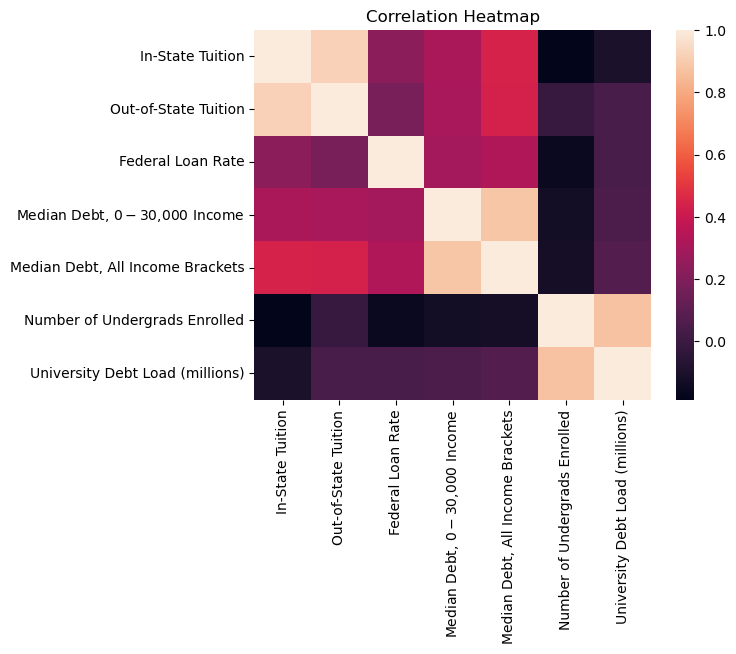

In [53]:
num_cols = [
    "In-State Tuition","Out-of-State Tuition","Federal Loan Rate",
    "Median Debt, $0-$30,000 Income","Median Debt, All Income Brackets",
    "Number of Undergrads Enrolled","University Debt Load (millions)"
]
corr = edu_income[num_cols].corr()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

There is a weak positive relationship between in-state tuition and median annual for low income families, a slightly stronger relationship between in-state tuition and medium income families, and a stronger yet relationship between in-state tuition and higher income families. It is possible that low-income families are able to receive grants or sholarships that allow them to have a slightly lower debt than their medium and higher income families. 

There is little to no relationship between a state's median annual salary and in-state tuition. There is a strong positive relationship between the number of undergrads enrolled in a university and the university's debt load. This makes sense. More students means more students that need aid.

#### Figure 3: Scatterplot, In-State Tuition vs. Student Debt of Low-Income Students

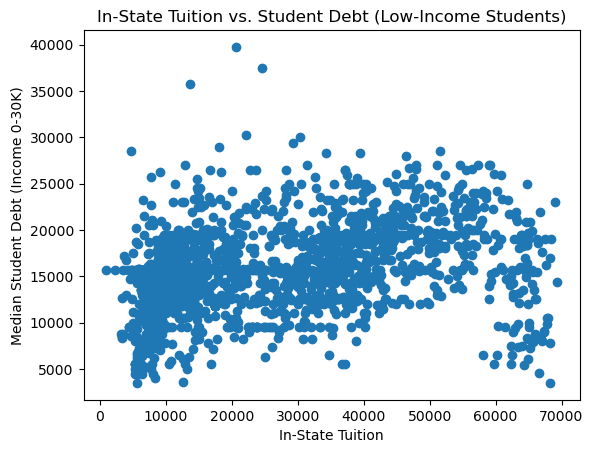

In [54]:
plt.scatter(
    edu_income["In-State Tuition"],
    edu_income["Median Debt, $0-$30,000 Income"]
)

plt.xlabel("In-State Tuition")
plt.ylabel("Median Student Debt (Income 0-30K)")
plt.title("In-State Tuition vs. Student Debt (Low-Income Students)")
plt.show()

This scatterplot shows the weak positive relationship between in-state tuition and student loan debt for low-income students. Schools with similar tuition levels have different debt outcomes. This suggests that other factors, such as financial aid and university pricing, also contribute to student borrowing.

In [55]:
#reshaping data to show how debt differs across income levels
debt_income = edu_income[[
    "Median Debt, $0-$30,000 Income",
    "Median Debt, $30,001-$75,000 Income",
    "Median Debt, $75,000+ Income",
]].melt(var_name="income_group", value_name="debt")

#### Figure 4: Boxplot, Median Student Debt by Family Income Group

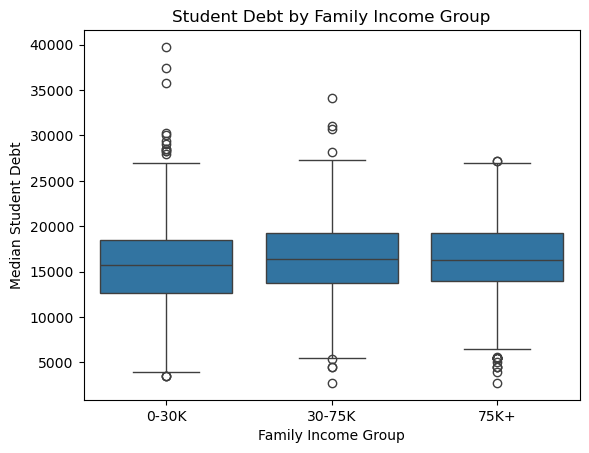

In [56]:
sns.boxplot(x="income_group", y="debt", data=debt_income)
plt.xlabel("Family Income Group")
plt.ylabel("Median Student Debt")
plt.title("Student Debt by Family Income Group")
plt.xticks([0,1,2], ["0-30K", "30-75K", "75K+"])
plt.show()

Student loan debt is similar across family income groups and institution. This suggests that tuition policies and financial aid packages shape student borrowing more than family income. Outliers in this boxplot show the wide variance within each income group. The direction of these outliers matches the logical flow of student loan debt and family income. For example, there are a signficant number of outliers above the box plot for the lowest family income group (0 - 30k) which means that the poorest families require the most student loan debt. In contrast, the significant number of outliers below the box plot for the highest family income group ($75k+) which means that the wealthiest families require the least amount of student loan debt.

#### Figure 5: Boxplot, Median Student Debt for Low-Income Families by Institution Type

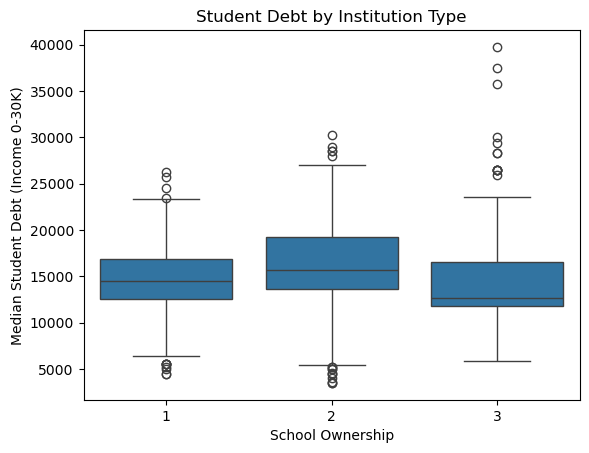

In [57]:
sns.boxplot(
    x="Ownership",
    y="Median Debt, $0-$30,000 Income",
    data=edu_income
)

plt.xlabel("School Ownership")
plt.ylabel("Median Student Debt (Income 0-30K)")
plt.title("Student Debt by Institution Type")
plt.show()

This information would allow for administrators to compare low-income student debt against peer institutions. The significant number and breadth of the outliers for the non-profit school ownership group (3) shows that some students are required to take on far more student loan debt than their public and private school ownership counterparts. 

In [58]:
#starting table on row 4 where header starts
delinq_df = pd.read_csv('Borrowers with Student Loans in Deliquency.csv', header=5) 

In [59]:
#checking for data inconsistencies
delinq_df.info 

<bound method DataFrame.info of                    State  \
0                Alabama   
1                 Alaska   
2                Arizona   
3               Arkansas   
4             California   
5               Colorado   
6            Connecticut   
7               Delaware   
8   District of Columbia   
9                Florida   
10               Georgia   
11                Hawaii   
12                 Idaho   
13              Illinois   
14               Indiana   
15                  Iowa   
16                Kansas   
17              Kentucky   
18             Louisiana   
19                 Maine   
20              Maryland   
21         Massachusetts   
22              Michigan   
23             Minnesota   
24           Mississippi   
25              Missouri   
26               Montana   
27              Nebraska   
28                Nevada   
29         New Hampshire   
30            New Jersey   
31            New Mexico   
32              New York   
33        North 

In [60]:
#drops empty columns to the right
delinq_df = delinq_df.dropna(axis=1, how='all') 

#names columns
delinq_df.columns = ['State', 'Delinquent_Student_Loans_Q12020', 'Delinquent_Student_Loans_Q12025']

In [61]:
#adds column for the percentage point change in state student loan delinquency
delinq_df['Delinq_%Point_Change'] = (
    delinq_df['Delinquent_Student_Loans_Q12025'] 
- delinq_df['Delinquent_Student_Loans_Q12020']
)

In [62]:
delinq_df.sample(10)

,State,Delinquent_Student_Loans_Q12020,Delinquent_Student_Loans_Q12025,Delinq_%Point_Change
48,Washington,14.7,21.1,6.4
28,Nevada,23.2,27.4,4.2
20,Maryland,17.2,25.4,8.2
30,New Jersey,13.7,19.9,6.2
36,Oklahoma,26.9,33.6,6.7
11,Hawaii,22.3,26.6,4.3
23,Minnesota,14.6,18.9,4.3
22,Michigan,20.4,27.7,7.3
35,Ohio,20.9,28.1,7.2
21,Massachusetts,11.0,14.0,3.0


In [63]:
delinq_BLS = delinq_df.merge(state, on="State", how="left")
delinq_BLS.shape  

(52, 5)

In [64]:
#checks for nulls/consistency between the data sets
delinq_BLS[['Median Annual Salary', 'Delinquent_Student_Loans_Q12025']].isna().sum()

Median Annual Salary               1
Delinquent_Student_Loans_Q12025    0
dtype: int64

In [65]:
#identifies which state has null
delinq_BLS.loc[
    delinq_BLS['Median Annual Salary'].isna(),
    ['State', 'Median Annual Salary']
    ]

,State,Median Annual Salary
39,Puerto Rico,NaN


In [66]:
delinq_income = delinq_BLS.dropna(subset=['Median Annual Salary'])

Puerto Rico was removed because the BLS dataset used for state wages does not report a median annual salary for Puetro Rico. Additionally, our university data focuses on US states.

#### Min/Max/Percentiles Table: Delinquent Loans and Median Annual Salary

In [67]:
delinq_income.describe()

,Delinquent_Student_Loans_Q12020,Delinquent_Student_Loans_Q12025,Delinq_%Point_Change,Median Annual Salary
count,51.000000,51.000000,51.000000,51.000000
mean,18.986275,23.603922,4.617647,50586.078431
std,4.921098,6.603604,3.440739,7522.918869
min,10.500000,13.700000,-4.500000,39070.000000
25%,14.800000,19.250000,2.900000,46455.000000
50%,18.100000,22.900000,4.400000,48550.000000
75%,22.300000,28.050000,6.700000,53325.000000
max,29.600000,44.600000,15.000000,88000.000000


In [68]:
#shows top increases in student loan delinquency percentage points
delinq_income.sort_values(
    "Delinq_%Point_Change",
    ascending=False
).head(10)
            

,State,Delinquent_Student_Loans_Q12020,Delinquent_Student_Loans_Q12025,Delinq_%Point_Change,Median Annual Salary
24,Mississippi,29.6,44.6,15.0,39070.0
51,Wyoming,16.0,26.4,10.4,49160.0
32,New York,13.5,23.0,9.5,58560.0
44,Texas,20.4,29.7,9.3,47500.0
20,Maryland,17.2,25.4,8.2,58050.0
49,West Virginia,26.0,34.0,8.0,43320.0
0,Alabama,26.4,34.1,7.7,43830.0
14,Indiana,20.4,28.0,7.6,46930.0
22,Michigan,20.4,27.7,7.3,48300.0
35,Ohio,20.9,28.1,7.2,48060.0


In [69]:
# shows states with the lowest median annual salary
delinq_income.sort_values(
    "Median Annual Salary",
    ascending=True
).head(10)
       

,State,Delinquent_Student_Loans_Q12020,Delinquent_Student_Loans_Q12025,Delinq_%Point_Change,Median Annual Salary
24,Mississippi,29.6,44.6,15.0,39070.0
3,Arkansas,27.8,33.5,5.7,41020.0
49,West Virginia,26.0,34.0,8.0,43320.0
18,Louisiana,27.0,31.8,4.8,43770.0
0,Alabama,26.4,34.1,7.7,43830.0
36,Oklahoma,26.9,33.6,6.7,43950.0
41,South Carolina,24.6,20.1,-4.5,44760.0
42,South Dakota,12.3,15.1,2.8,45620.0
17,Kentucky,27.0,33.6,6.6,45740.0
31,New Mexico,24.6,28.5,3.9,45870.0


Mississippi, West Virginia, and Alabama are the only states that have top increases in student loan delinquency percentage point change from 2020 to 2025 and one of the lowest median annual salaries. This suggests that there are other factors outside of median annual salary that is affecting student loan delinquency rates.

#### Correlation: Median Annual Salary and Delinquent Student Loans

In [70]:
delinq_income["Median Annual Salary"].corr(delinq_income["Delinquent_Student_Loans_Q12020"])

np.float64(-0.6491985661556143)

This correlation shows that as median annual salary increases, the percentage of delinquent student loans decreases. Higher-wage states tend to have lower student loan delinquency rates in 2020.

In [71]:
delinq_income["Median Annual Salary"].corr(delinq_income["Delinquent_Student_Loans_Q12025"])

np.float64(-0.5208516510128015)

This correlation shows that as median annual salary increases, the percentage of delinquent student loans decreases. Higher-wage states tend to have lower student loan delinquency rates in 2025. However, the relationship is slightly weaker than it was in 2020.

In [72]:
delinq_income["Median Annual Salary"].corr(delinq_income["Delinq_%Point_Change"])

np.float64(-0.07112660840021152)

There is no linear relationship between median annual salary and change in student loan delinquency. Wage levels did not predict how delinquency changed between 2020 and 2025. Delinquency increased at similar rates across states.

#### Figure 6: Heatmap, Median Annual Salary and Student Loan Delinquency

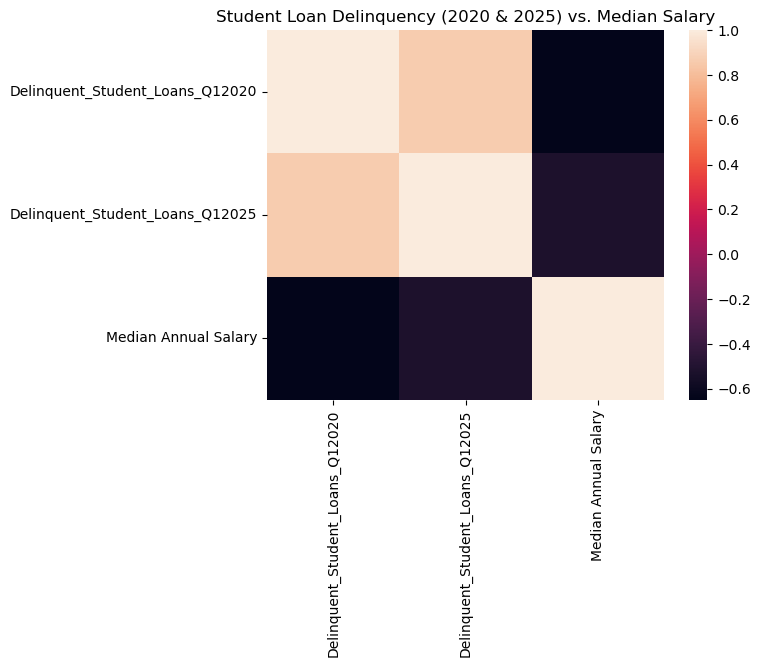

In [73]:
num_cols = [
    "Delinquent_Student_Loans_Q12020","Delinquent_Student_Loans_Q12025",
    "Median Annual Salary"
]
corr = delinq_income[num_cols].corr()
sns.heatmap(corr, annot=False)
plt.title("Student Loan Delinquency (2020 & 2025) vs. Median Salary")
plt.show() 

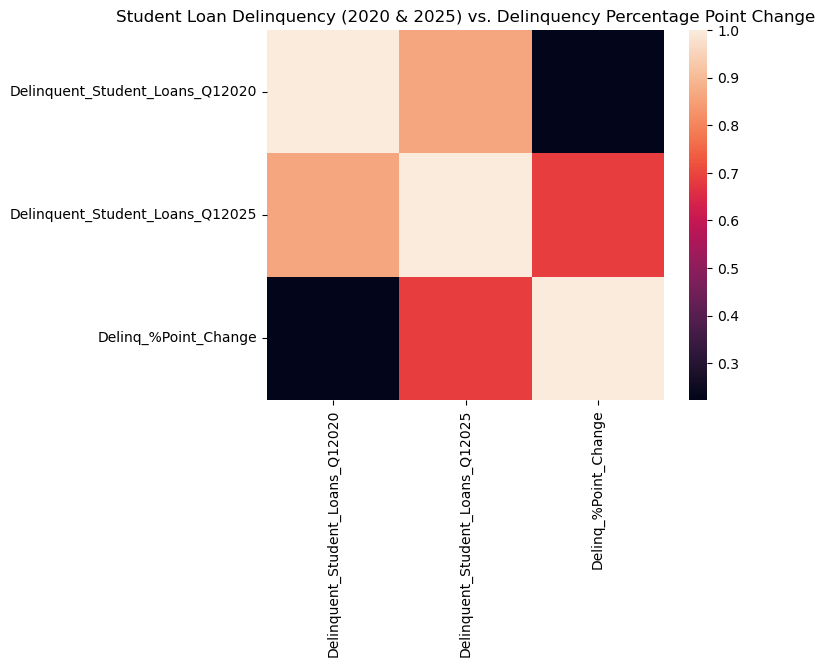

In [74]:
num_cols = [
    "Delinquent_Student_Loans_Q12020","Delinquent_Student_Loans_Q12025",
    "Delinq_%Point_Change"
]
corr = delinq_income[num_cols].corr()
sns.heatmap(corr, annot=False)
plt.title("Student Loan Delinquency (2020 & 2025) vs. Delinquency Percentage Point Change")
plt.show() 

Student loan delinquency rates are moderately correlated with median annual salary. There is not a strong correlation between student loan delinquency percentage point changes and median annual salary. This suggests that there may be other factors influencing the increase in student loan delinquency, including the economic environment.

#### Wage Quartile and Student Loan Delinquency

In [75]:
#creating four wage quartiles based on median annual salary data
delinq_income["Median Salary Quartile"] = pd.qcut(delinq_income["Median Annual Salary"], 4,
    labels=[
    "Lowest Salary States",
    "Lower-Middle Salary States",
    "Upper-Middle Salary States",
    "Highest Salary States"
    ]
)

In [76]:
delinq_income.groupby("Median Salary Quartile")[
["Delinquent_Student_Loans_Q12020", "Delinquent_Student_Loans_Q12025","Delinq_%Point_Change"]
    ].median()

,Delinquent_Student_Loans_Q12020,Delinquent_Student_Loans_Q12025,Delinq_%Point_Change
Median Salary Quartile,,,
Lowest Salary States,26.00,31.8,5.70
Lower-Middle Salary States,20.40,22.0,4.10
Upper-Middle Salary States,15.35,19.5,4.05
Highest Salary States,15.50,20.5,5.30


All wage quartiles saw between a 4-6 percentage point increase in student loan delinquency, with the largest increases found in the first and fourth salary quartile.

#### Figure 7: Boxplot, Median Salary and Student Loan Delinquency

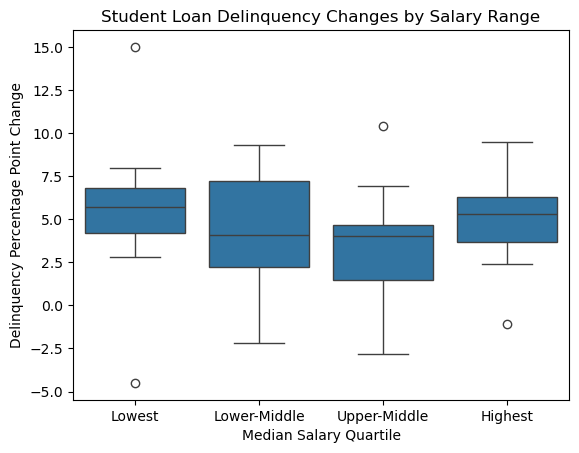

In [77]:
sns.boxplot(x="Median Salary Quartile", y="Delinq_%Point_Change", data=delinq_income)
plt.xlabel("Median Salary Quartile")
plt.ylabel("Delinquency Percentage Point Change")
plt.title("Student Loan Delinquency Changes by Salary Range")
plt.xticks([0,1,2,3], ["Lowest", "Lower-Middle", "Upper-Middle", "Highest"])
plt.show()

Most states saw a similar increase in delinquency rates between 2020 and 20205, showing that there is  not a strong relationship between salary and delinquency changes. The first quartile shows two extreme outliers which suggests that there might be slightly more variability in delinquency rates among student loan borrowers within the lowest salaries.

#### Figure 8: Scatterplot, Median Salary and Student Loan Delinquency

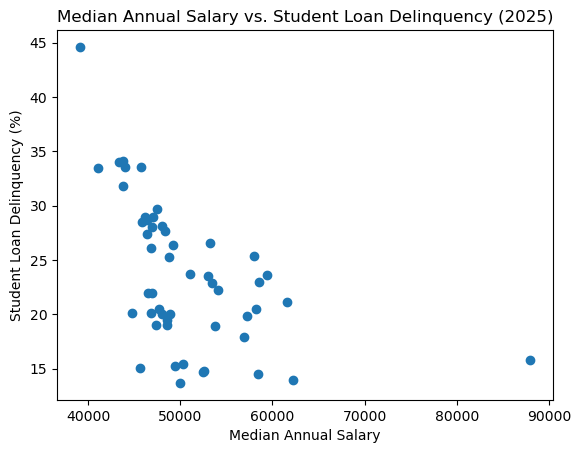

In [78]:
plt.scatter(
    delinq_income["Median Annual Salary"],
    delinq_income["Delinquent_Student_Loans_Q12025"]
)

plt.xlabel("Median Annual Salary")
plt.ylabel("Student Loan Delinquency (%)")
plt.title("Median Annual Salary vs. Student Loan Delinquency (2025)")
plt.show()

Student Loan Delinquency (2025) is concentrated between $42K-60K median annual salary.

#### Figure 9: Histogram, Student Loan Delinquency over time

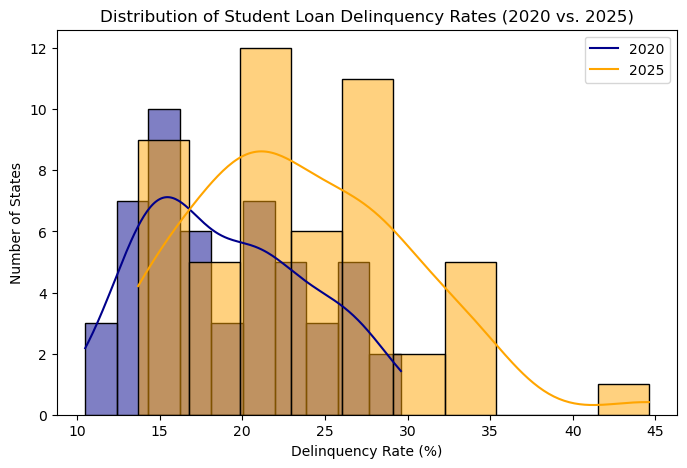

In [79]:
plt.figure(figsize=(8,5))

sns.histplot(
    delinq_income["Delinquent_Student_Loans_Q12020"],
    color="darkblue",
    label = "2020",
    bins=10,
    kde=True
)

sns.histplot(
    delinq_income["Delinquent_Student_Loans_Q12025"],
    color="orange",
    label = "2025",
    bins=10,
    kde=True
)  

plt.title ("Distribution of Student Loan Delinquency Rates (2020 vs. 2025)")
plt.xlabel ("Delinquency Rate (%)")
plt.ylabel("Number of States")

plt.legend(["2020", "2025"], loc= "upper right")

The histogram highlights the significant increases in delinquency rate between 2020 and 2025 across states, including a significant outlier in Mississipi with a 44% student loan delinquency rate in 2025 compared to a 30% in 2020.

#### Model #2: Linear Regression

In [80]:
X = delinq_income.loc[:,'Median Annual Salary'].values.reshape(-1,1)
y = delinq_income.loc[:,'Delinquent_Student_Loans_Q12025']

lin_reg = LinearRegression()
lin_reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [81]:
lin_reg.coef_

array([-0.0004572])

This shows that there is not a strong change in delinquent student loans in 2025 based on median annual salary. For every $1 increase in median salary, the delinquency rate decreases by 0.00046 percentage points.

In [82]:
lin_reg.intercept_

np.float64(46.73200762164636)

In [83]:
lin_reg.predict([[0]])

array([46.73200762])

# Conclusion

#### Key Takeaways
Universities do not operate within a vacuum. Students and their families must evalute a multitude of factors to determine where their student should get a college education, including the cost of tuition (either in-state or out-of-state), how much student loan debt they must take on, and the extent to which the state they live or go to school can provide sufficient salary potential.

While there is a moderate relationship between median annual salary and student loan delinquency rates, there are likely other factors that are currently influenced student loan delinquency in 2025 compared to 2020 including economic conditions. Student loan borrowers of all salary ranges from many states are experiencing difficulties with maintaining student loan payments. This presents an opportunity for university administrators to consider what financial levers may be pulled to ensure that alumni are not saddled by student loan debt long-term, which may encourage younger generations to pursue higher education.

Further, the SQL related analysis (separate file) digs into the relationship of rising tuition levels and wages by state over about a 10 year period. The results show that tuition and median wages have been steadily rising at comparable rates with tuition increasing at a slightly faster rate, contributing to affordability issues of higher education. Additionally, significant variation in debt and wages levels around the US indicates geographic location and institutional pricing strategies play a role in shaping student debt outcomes across income brackets.

Overall, the results from the above analysis highlight the importance of institutional interventions to help students and their families manage student loan debt burden. University Administrators must consider these factors, review how their institution differs from comparable institutions or institutions in nearby states, and assess the extent to which students can afford the cost of tuition if they were to stay in-state and make the state median income.

#### Opportunity for future work 
The above analysis provided insights into tuition costs and student loan debt burden across the United States at 4-year undergraduate institutions. To gain a better understanding of economic context and financial responsibilities among student loan borrowers, additional research should explore trends in student loan interest rates, unemployment rates, and credit card debt delinquency. 